# The Derivative of $\log(x)$

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture on **the derivative of the
logarithm** (Week 1 — Derivatives and Optimization).

This notebook explains:

- what the (natural) logarithm is: $\ln x$ is the number with $e^{(\,\cdot\,)} = x$
- that $\ln$ is the **inverse** of $e^x$ ($e^{\ln x} = x$, $\ln(e^y) = y$)
- using the **inverse-function rule** to get $\dfrac{d}{dy}\ln y = \dfrac{1}{y}$
- the geometry (reflection over $y = x$, reciprocal slopes) and SymPy verification

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*The Derivative of $e^x$* and *The Inverse Function and Its Derivative*.

## 1. What is a logarithm?

The **logarithm** of $x$ is the number you must raise $e$ to in order to get $x$:

$$
e^{\,\ln x} = x .
$$

So $\ln 3$ is the number with $e^{\ln 3} = 3$. This is the **natural logarithm** (base $e$).
Other bases (2, 10) exist, but in this course "$\log$" always means natural log $\ln$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# ln(x) is the exponent that returns x
for v in [3, 1, np.e, 10]:
    print(f"ln({v:.4f}) = {np.log(v):.4f}   ->   e^(that) = {np.exp(np.log(v)):.4f}")

ln(3.0000) = 1.0986   ->   e^(that) = 3.0000
ln(1.0000) = 0.0000   ->   e^(that) = 1.0000
ln(2.7183) = 1.0000   ->   e^(that) = 2.7183
ln(10.0000) = 2.3026   ->   e^(that) = 10.0000


## 2. $\ln$ is the inverse of $e^x$

Because $e^{\ln x} = x$ and $\ln(e^y) = y$, the function $f(x) = e^x$ has inverse
$g(y) = \ln y$:

$$
f^{-1}(y) = \ln y .
$$

Their graphs are **reflections** of each other over the line $y = x$.

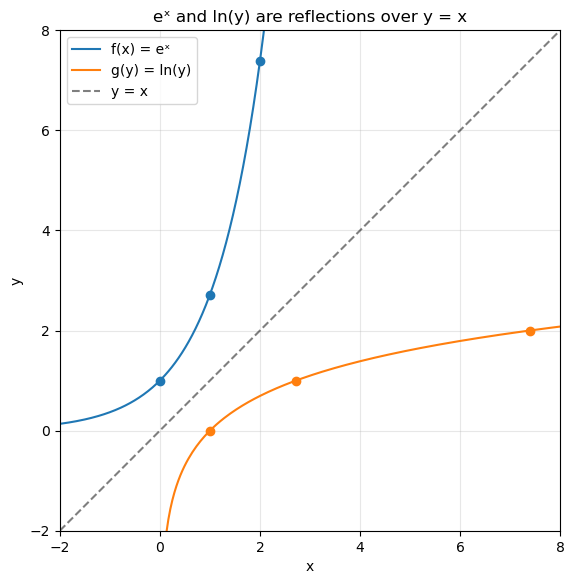

In [2]:
xs = np.linspace(-2, 2.5, 200)
xp = np.linspace(0.05, 8, 200)

plt.figure(figsize=(6.5, 6.5))
plt.plot(xs, np.exp(xs), label="f(x) = eˣ")
plt.plot(xp, np.log(xp), label="g(y) = ln(y)")
plt.plot(np.linspace(-2, 8, 10), np.linspace(-2, 8, 10), "k--", alpha=0.5, label="y = x")
for a, b in [(0, 1), (1, np.e), (2, np.e**2)]:
    plt.plot(a, b, "o", color="tab:blue")
    plt.plot(b, a, "o", color="tab:orange")
plt.title("eˣ and ln(y) are reflections over y = x")
plt.xlabel("x"); plt.ylabel("y")
plt.gca().set_aspect("equal"); plt.xlim(-2, 8); plt.ylim(-2, 8)
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

## 3. The derivative via the inverse rule

The inverse-function rule says $g'(y) = \dfrac{1}{f'(x)}$ where $y = f(x)$.

Take the point $x = 2$: the height is $e^2 = 7.39$, and since $f'(x) = e^x$, the slope of
$e^x$ there is also $e^2 = 7.39$. On the reflected graph the corresponding point is
$(e^2,\, 2)$, and its slope is the **reciprocal**:

$$
g'(e^2) = \frac{1}{e^2}.
$$

Since the input is $y = e^2$, this is $\dfrac{1}{y}$. The same holds at every point:

$$
\boxed{\;\frac{d}{dy}\ln y = \frac{1}{y}.\;}
$$

### The formal derivation

$$
\frac{d}{dy}\,f^{-1}(y) = \frac{1}{f'(x)} = \frac{1}{f'\!\big(f^{-1}(y)\big)}.
$$

With $f'(x) = e^x$ and $f^{-1}(y) = \ln y$:

$$
\frac{d}{dy}\ln y = \frac{1}{e^{\ln y}} = \frac{1}{y}.
$$

In [3]:
x, y = sp.symbols('x y', positive=True)

# inverse rule: 1 / f'(f^{-1}(y)) with f'=e^x, f^{-1}=ln y
fprime = sp.exp(x)
result = 1 / fprime.subs(x, sp.ln(y))
print("1 / e^(ln y) =", sp.simplify(result))          # 1/y
print("SymPy d/dy ln(y) =", sp.diff(sp.ln(y), y))      # 1/y

# reciprocal-slope check at y = e^2
print("slope of eˣ at x=2:", float(fprime.subs(x, 2)),
      " -> ln' at y=e²:", float(sp.diff(sp.ln(y), y).subs(y, sp.exp(2))))

1 / e^(ln y) = 1/y
SymPy d/dy ln(y) = 1/y
slope of eˣ at x=2: 7.38905609893065  -> ln' at y=e²: 0.1353352832366127


## 4. Visualizing

$\ln(x)$ and its derivative $\dfrac{1}{x}$: the log grows ever more slowly, and its slope
$1/x$ shrinks toward $0$ as $x$ increases (and blows up near $0$).

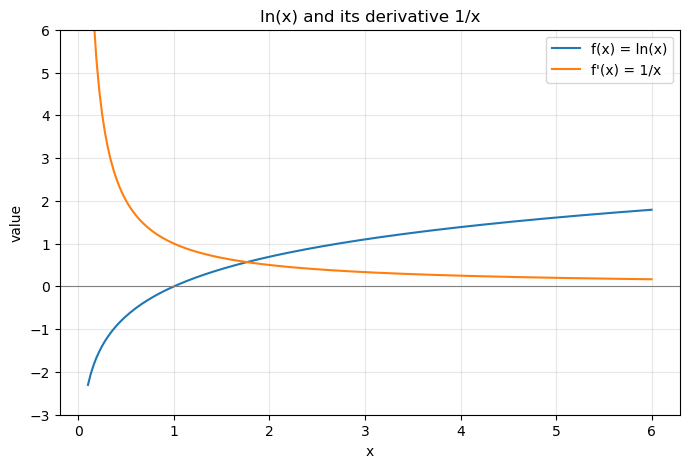

In [4]:
xp = np.linspace(0.1, 6, 200)

plt.figure(figsize=(8, 5))
plt.plot(xp, np.log(xp), label="f(x) = ln(x)")
plt.plot(xp, 1/xp, label="f'(x) = 1/x")
plt.axhline(0, color="gray", lw=0.8)
plt.title("ln(x) and its derivative 1/x")
plt.xlabel("x"); plt.ylabel("value")
plt.ylim(-3, 6); plt.grid(True, alpha=0.3); plt.legend()
plt.show()

## 5. Exercises

### Basic
1. What is $\ln x$ defined to be (in terms of $e$)?
2. What is the derivative of $\ln x$?

### Intermediate
3. What is the slope of $\ln x$ at $x = 1$? At $x = e$? At $x = e^2$?
4. Estimate the slope of $\ln x$ at $x = 2$ numerically and compare to $1/x$.

### Advanced
5. Using $g'(y) = 1/f'(x)$, re-derive $\dfrac{d}{dy}\ln y = \dfrac{1}{y}$ from $f(x) = e^x$.
6. Using the chain rule (preview), what is $\dfrac{d}{dx}\ln(3x)$? Simplify.

## 6. Solutions / Checks

In [5]:
y = sp.symbols('y', positive=True)

# 3.
dln = sp.diff(sp.ln(y), y)
for val, name in [(1, "1"), (sp.exp(1), "e"), (sp.exp(2), "e²")]:
    print(f"3. ln' at y={name}: {sp.simplify(dln.subs(y, val))}")

# 4.
dx = 1e-6
print(f"4. numeric slope of ln at 2: {(np.log(2+dx)-np.log(2))/dx:.6f}  (exact 1/2 = 0.5)")

# 5.
x = sp.symbols('x', positive=True)
print("5. 1/f'(f^-1(y)) =", sp.simplify(1/sp.exp(x).subs(x, sp.ln(y))))

# 6.
print("6. d/dx ln(3x) =", sp.simplify(sp.diff(sp.ln(3*x), x)), " (= 1/x, since ln(3x)=ln3+lnx)")

print("\n1. ln x is the exponent with e^(ln x) = x (natural log, base e).")
print("2. 1/x.")

3. ln' at y=1: 1
3. ln' at y=e: exp(-1)
3. ln' at y=e²: exp(-2)
4. numeric slope of ln at 2: 0.500000  (exact 1/2 = 0.5)
5. 1/f'(f^-1(y)) = 1/y
6. d/dx ln(3x) = 1/x  (= 1/x, since ln(3x)=ln3+lnx)

1. ln x is the exponent with e^(ln x) = x (natural log, base e).
2. 1/x.


## 7. Conclusion

- The natural logarithm $\ln x$ is the inverse of $e^x$: $e^{\ln x} = x$ and
  $\ln(e^y) = y$, so their graphs reflect over $y = x$.
- Applying the inverse-function rule $g'(y) = \dfrac{1}{f'(x)}$ with $f'(x) = e^x$ gives

$$
\frac{d}{dy}\ln y = \frac{1}{e^{\ln y}} = \frac{1}{y}.
$$

- So the derivative of the logarithm is simply $\dfrac{1}{x}$ — small for large $x$, large
  near $0$.
- This completes the common derivatives (polynomials, power functions, $e^x$, $\ln x$, and
  trig), the toolkit for the optimization that follows.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/index (15).mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 1) lecture **the derivative of $\log(x)$** (the transcript's "7.89" is a
mis-hearing of $e^2 = 7.39$). Key spoken points, lightly cleaned:

> Using the exponential $e^x$ (whose derivative is $e^x$) and the inverse-function rule, we
> find the derivative of the logarithm. The logarithm of $x$ is the number such that
> $e^{(\cdot)} = x$ — the natural logarithm (base $e$); here $\log$ always means $\ln$. Since
> $e^{\ln x} = x$ and $\ln(e^y) = y$, $f(x) = e^x$ has inverse $\ln y$, and their graphs are
> reflections over $y = x$. Take $x = 2$: the height and slope of $e^x$ are both $e^2 =
> 7.39$, so on the reflected graph at $(e^2, 2)$ the slope is the reciprocal $1/e^2 = 1/y$.
> Formally, $\frac{d}{dy} f^{-1}(y) = 1/f'(f^{-1}(y)) = 1/e^{\ln y} = 1/y$. So the derivative
> of $\ln y$ is $1/y$.